# Advance Bank Term Deposit

## Introduction
This notebook provides a detailed analysis of customer behavior and insights into factors influencing term deposit subscription. The dataset comes from a Portuguese bank's direct marketing campaigns (phone calls) and contains client demographics, contact details, campaign info, and macroeconomic indicators. The goal is to understand what drives clients to subscribe to a term deposit and to build a predictive model.

## Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

# Load data
df = pd.read_csv('data.csv')

print("Shape:", df.shape)
df.head()

Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [2]:
# Basic info and data quality check
df.info()
print("\nMissing values:\n", df.isnull().sum())
print("\nTarget distribution:\n", df['y'].value_counts())
print("\nSubscription rate: {:.2f}%".format(df['y'].eq('yes').mean() * 100))

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

## Customer Demographics Analysis

### Age Distribution

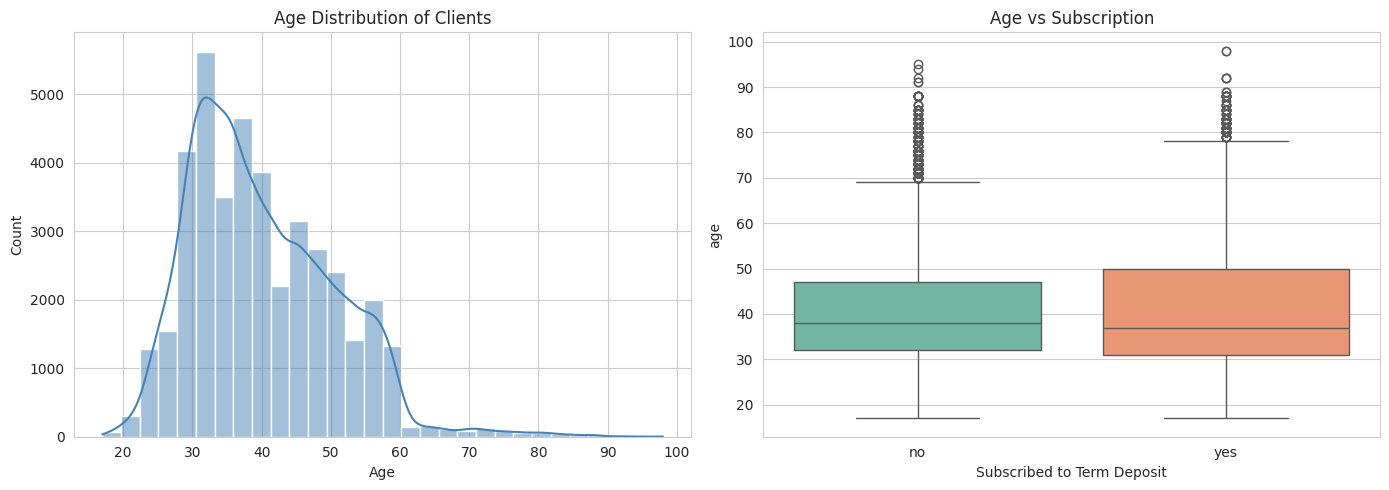

       count       mean        std   min   25%   50%   75%   max
y                                                               
no   36548.0  39.911185   9.898132  17.0  32.0  38.0  47.0  95.0
yes   4640.0  40.913147  13.837476  17.0  31.0  37.0  50.0  98.0


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['age'], bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Age Distribution of Clients')
axes[0].set_xlabel('Age')

sns.boxplot(x='y', y='age', data=df, ax=axes[1], hue='y', palette='Set2', legend=False)
axes[1].set_title('Age vs Subscription')
axes[1].set_xlabel('Subscribed to Term Deposit')

plt.tight_layout()
plt.show()

print(df.groupby('y')['age'].describe())

### Job Distribution

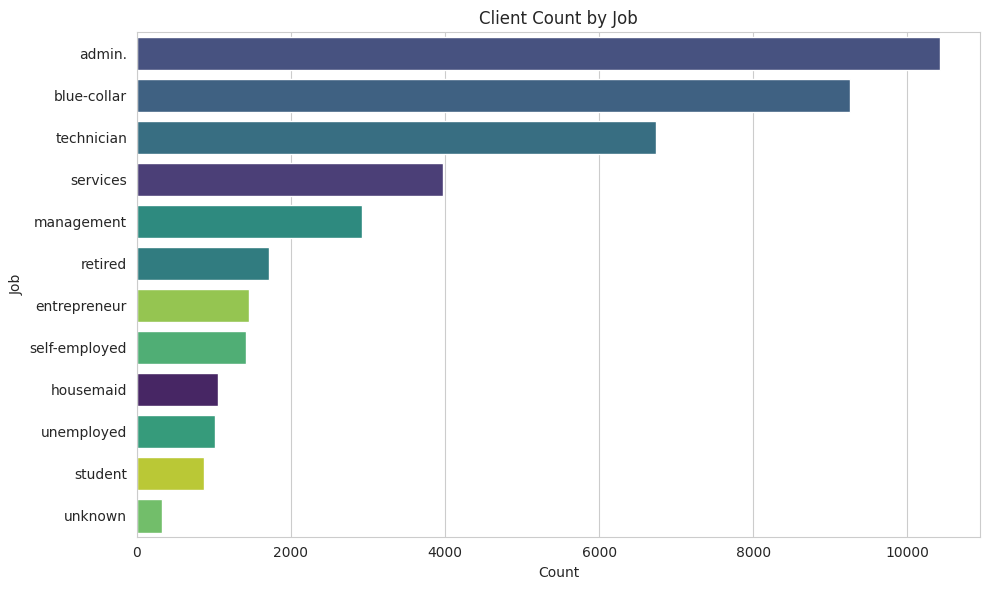

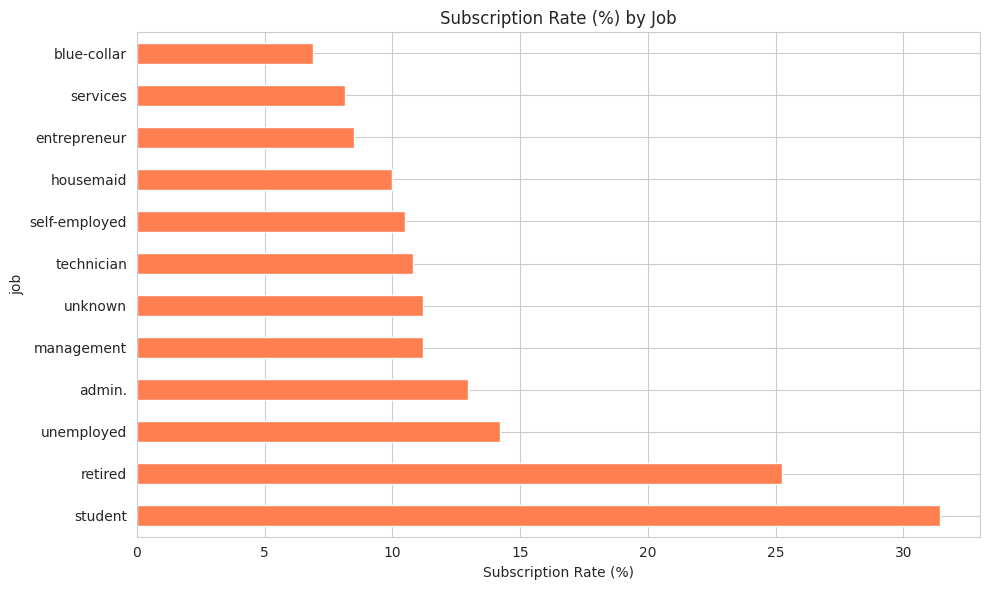

job
student          31.428571
retired          25.232558
unemployed       14.201183
admin.           12.972558
management       11.217510
unknown          11.212121
technician       10.826042
self-employed    10.485574
housemaid        10.000000
entrepreneur      8.516484
services          8.138070
blue-collar       6.894316
Name: y, dtype: float64


In [4]:
plt.figure(figsize=(10, 6))
job_order = df['job'].value_counts().index
sns.countplot(y='job', data=df, order=job_order, hue='job', palette='viridis', legend=False)
plt.title('Client Count by Job')
plt.xlabel('Count')
plt.ylabel('Job')
plt.tight_layout()
plt.show()

# Subscription rate by job
job_sub_rate = df.groupby('job')['y'].apply(lambda x: (x == 'yes').mean() * 100).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
job_sub_rate.plot(kind='barh', color='coral')
plt.title('Subscription Rate (%) by Job')
plt.xlabel('Subscription Rate (%)')
plt.tight_layout()
plt.show()

print(job_sub_rate)

## Balance & Deposit Trends

**Note:** This version of the dataset does not include an account `balance` column. Instead, we use **call `duration`** (last contact duration in seconds) as the key numeric driver of subscription, since it's the strongest available behavioral signal.

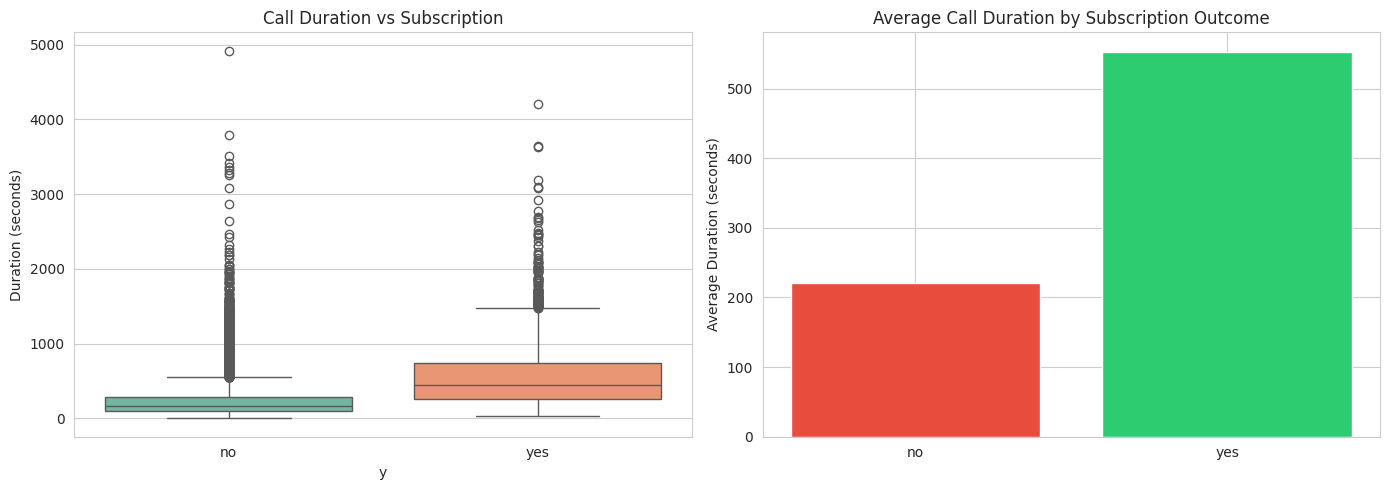

Average call duration:
 y
no     220.844807
yes    553.191164
Name: duration, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='y', y='duration', data=df, ax=axes[0], hue='y', palette='Set2', legend=False)
axes[0].set_title('Call Duration vs Subscription')
axes[0].set_ylabel('Duration (seconds)')

avg_duration = df.groupby('y')['duration'].mean()
axes[1].bar(avg_duration.index, avg_duration.values, color=['#e74c3c', '#2ecc71'])
axes[1].set_title('Average Call Duration by Subscription Outcome')
axes[1].set_ylabel('Average Duration (seconds)')

plt.tight_layout()
plt.show()

print("Average call duration:\n", avg_duration)

## Campaign Effectiveness

### Contact Method Analysis

<Figure size 700x500 with 0 Axes>

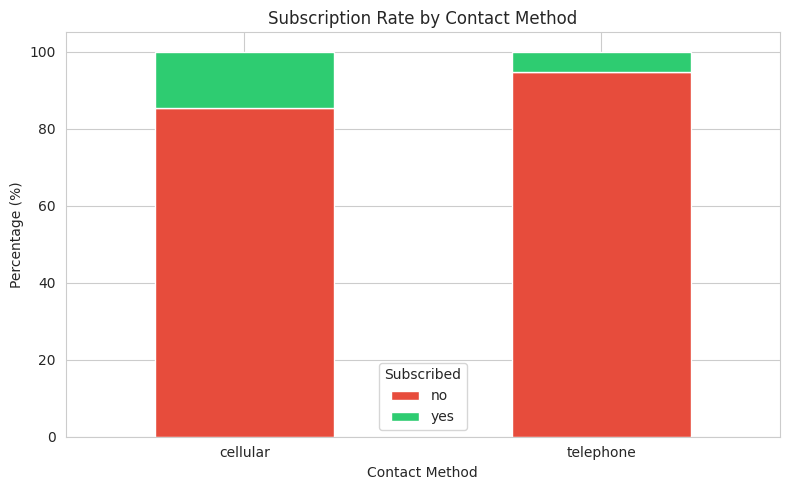

y                 no        yes
contact                        
cellular   85.262393  14.737607
telephone  94.768679   5.231321


In [6]:
plt.figure(figsize=(7, 5))
contact_sub = pd.crosstab(df['contact'], df['y'], normalize='index') * 100
contact_sub.plot(kind='bar', stacked=True, color=['#e74c3c', '#2ecc71'])
plt.title('Subscription Rate by Contact Method')
plt.ylabel('Percentage (%)')
plt.xlabel('Contact Method')
plt.legend(title='Subscribed')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(contact_sub)

### Number of Contacts vs Deposit Subscription

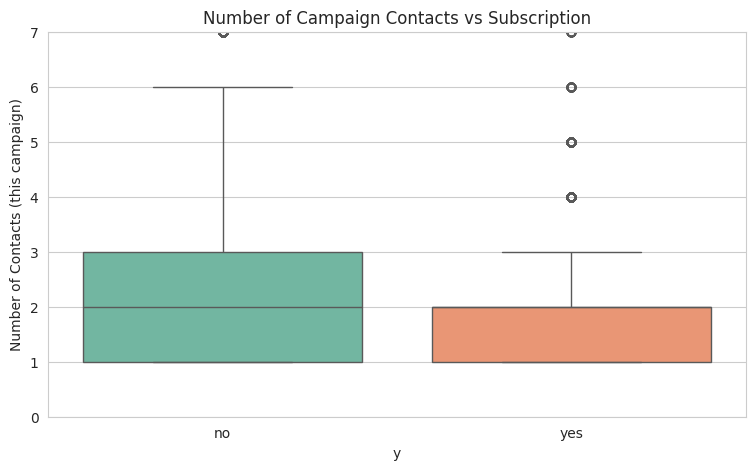

       count      mean       std  min  25%  50%  75%   max
y                                                         
no   36548.0  2.633085  2.873438  1.0  1.0  2.0  3.0  56.0
yes   4640.0  2.051724  1.666245  1.0  1.0  2.0  2.0  23.0


<Figure size 800x500 with 0 Axes>

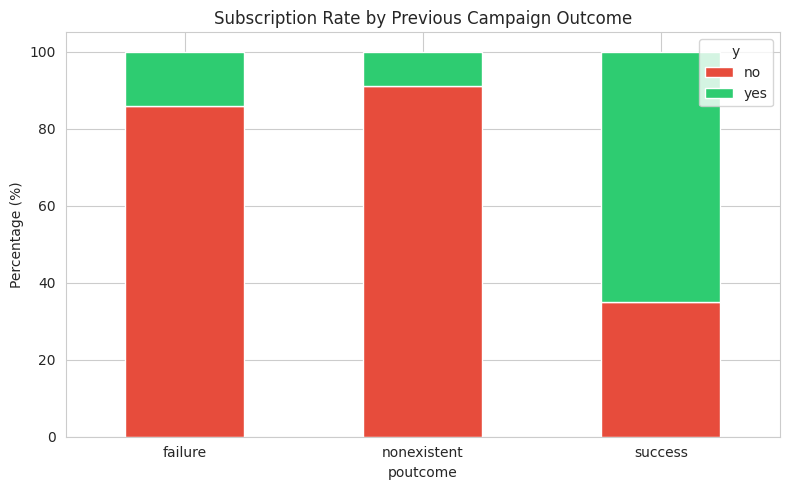

In [7]:
plt.figure(figsize=(9, 5))
sns.boxplot(x='y', y='campaign', data=df, hue='y', palette='Set2', legend=False)
plt.title('Number of Campaign Contacts vs Subscription')
plt.ylabel('Number of Contacts (this campaign)')
plt.ylim(0, df['campaign'].quantile(0.95))  # trim extreme outliers for readability
plt.show()

print(df.groupby('y')['campaign'].describe())

# Previous campaign outcome effect
plt.figure(figsize=(8, 5))
poutcome_sub = pd.crosstab(df['poutcome'], df['y'], normalize='index') * 100
poutcome_sub.plot(kind='bar', stacked=True, color=['#e74c3c', '#2ecc71'])
plt.title('Subscription Rate by Previous Campaign Outcome')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Correlation Heatmap

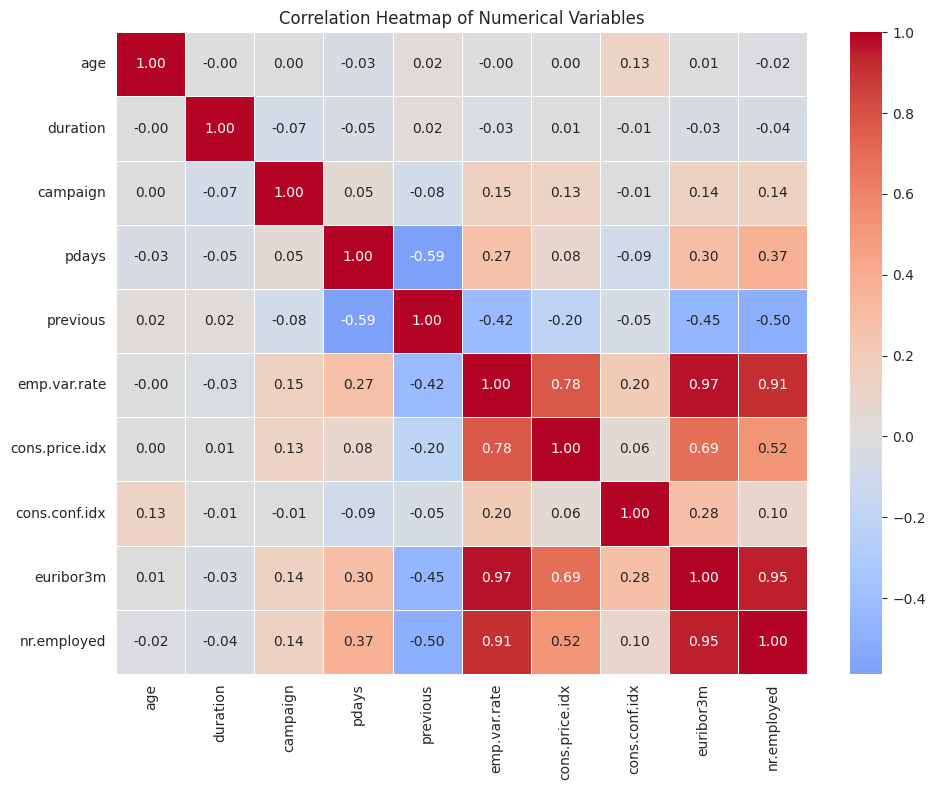

In [8]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Variables')
plt.tight_layout()
plt.show()

## Predictive Modeling (Logistic Regression)

We encode categorical variables using one-hot encoding, split the data into train/test sets, and train a logistic regression model to predict whether a client subscribes to a term deposit.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score, roc_curve)

# Encode target
df_model = df.copy()
df_model['y'] = df_model['y'].map({'no': 0, 'yes': 1})

# Encode categorical variables
categorical_cols = df_model.select_dtypes(include=['object', 'str']).columns.tolist()
df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train logistic regression
model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8653799465889779
ROC-AUC: 0.9438110288221143

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.86      0.92      7310
           1       0.45      0.91      0.60       928

    accuracy                           0.87      8238
   macro avg       0.72      0.89      0.76      8238
weighted avg       0.93      0.87      0.88      8238



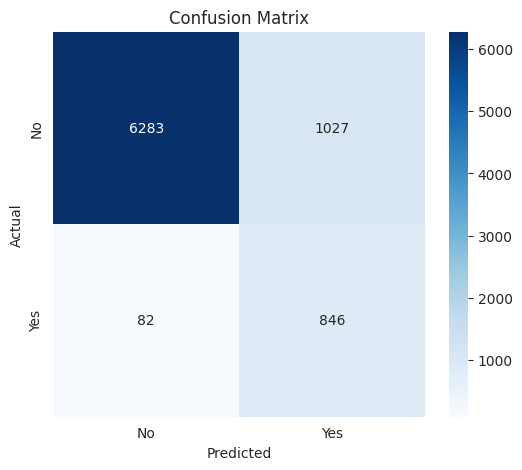

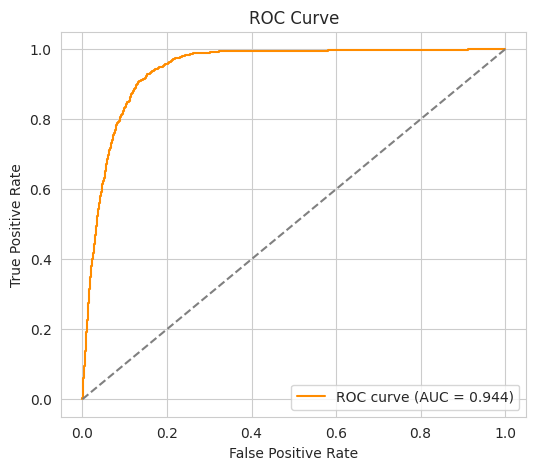

In [10]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc_score(y_test, y_proba):.3f})', color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

### Feature Importance

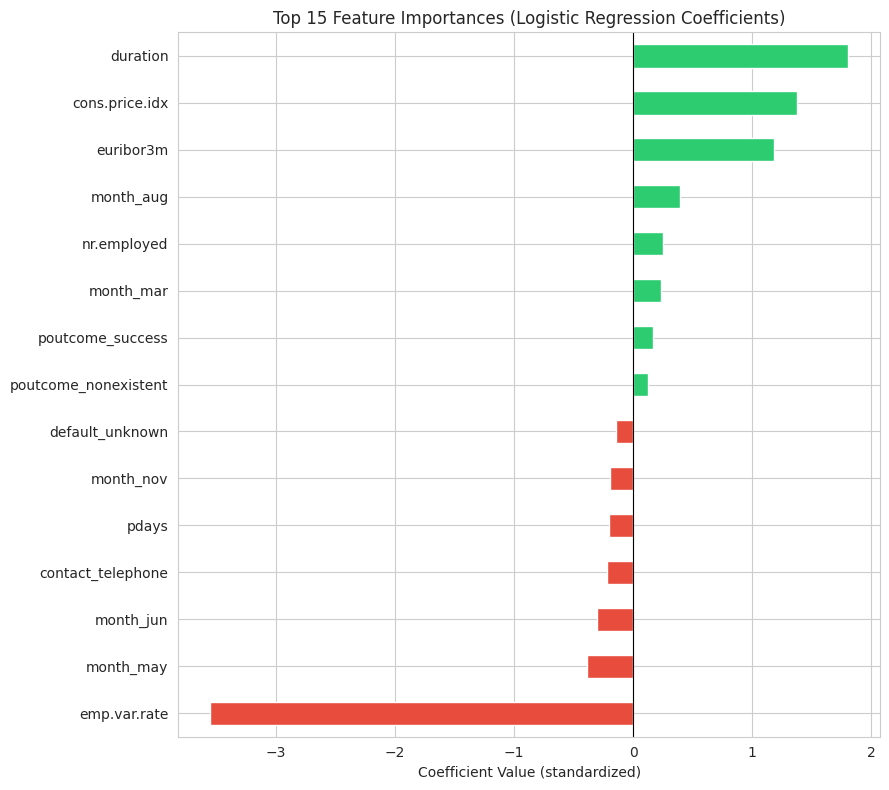

Top drivers (positive = increases likelihood of subscription):
duration                1.806199
cons.price.idx          1.378111
euribor3m               1.179860
month_aug               0.392085
nr.employed             0.253916
month_mar               0.236512
poutcome_success        0.168907
poutcome_nonexistent    0.129002
default_unknown        -0.145715
month_nov              -0.194159
pdays                  -0.205379
contact_telephone      -0.218880
month_jun              -0.300157
month_may              -0.384034
emp.var.rate           -3.551285
dtype: float64


In [11]:
coefficients = pd.Series(model.coef_[0], index=X.columns)
top_features = coefficients.abs().sort_values(ascending=False).head(15).index
top_coef = coefficients[top_features].sort_values()

plt.figure(figsize=(9, 8))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in top_coef.values]
top_coef.plot(kind='barh', color=colors)
plt.title('Top 15 Feature Importances (Logistic Regression Coefficients)')
plt.xlabel('Coefficient Value (standardized)')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print("Top drivers (positive = increases likelihood of subscription):")
print(coefficients[top_features].sort_values(ascending=False))

## Key Takeaways
- The overall subscription rate is low (~11%), so the dataset is imbalanced — this was handled with `class_weight='balanced'` in the model.
- **Call duration** is by far the strongest predictor: longer calls are strongly associated with subscription (naturally — a longer conversation usually means more genuine interest). Note this can't be known before a call is made, so it's not useful for *targeting* customers in advance, only for explaining outcomes.
- **Previous campaign outcome** (`poutcome = success`) is one of the strongest positive drivers — clients who subscribed before are much more likely to subscribe again.
- **Cellular contact** outperforms telephone contact in subscription rate.
- Clients contacted **fewer times** (lower `campaign` count) tend to have higher subscription rates — excessive contact attempts may hurt conversion.
- Certain **job categories** (e.g., students, retired) and **age groups** show higher subscription rates than others.
- Macroeconomic indicators (`euribor3m`, `emp.var.rate`, `nr.employed`) also show meaningful correlation with subscription, reflecting how broader economic conditions affect term deposit demand.
- The logistic regression model achieves reasonable discriminative power (see ROC-AUC), making it a solid interpretable baseline; tree-based models (Random Forest, XGBoost) could likely improve raw accuracy further at the cost of interpretability.